# Libraries & Set up

In [2]:
%run ../../../setup_workspace.py

ValueError: x and y must have same first dimension, but have shapes (2000,) and (1,)

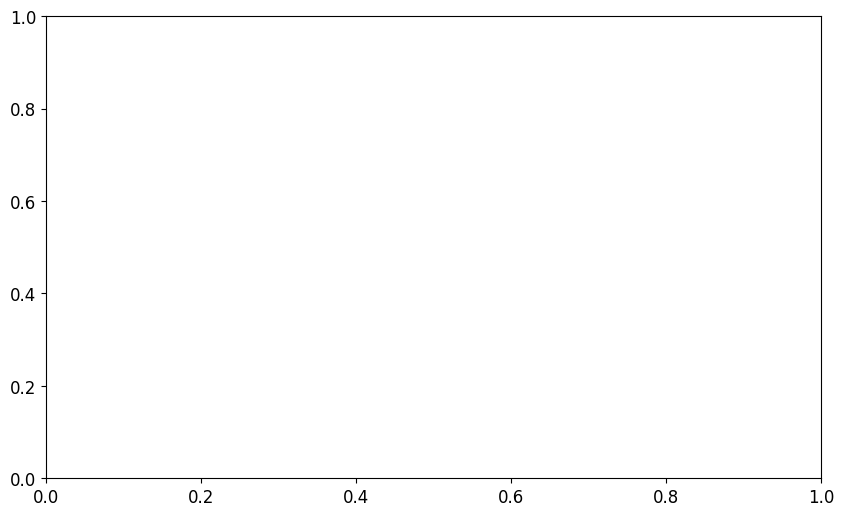

In [3]:
path = r'\\Synology\Data\2026\SC5782\RAW_DATA\Bottlebrush_PCL_PEG\Bottlebrush_PCL_PEG_PCL_PEG_20perc_20C_cryst_bis'

Exp = BM26_experiment(path)

q, I = Exp.get_1d_SAXS()
plt.plot(q, I[0])

In [46]:
Exp.get_Time_profile()[20]

np.int64(599)

Found 103 EDF files in SAXS


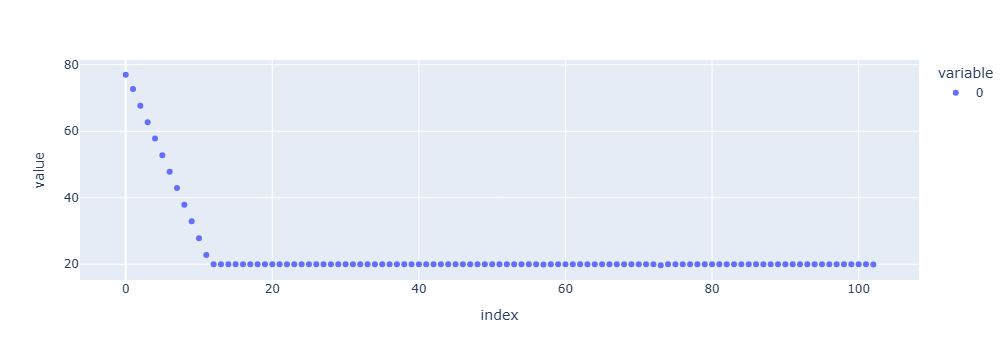

In [39]:
px.scatter(Exp.get_T_profile())

Text(0, 0.5, 'I (a.u.)')

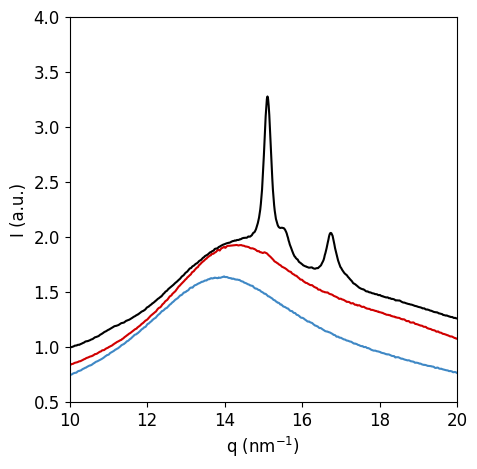

In [44]:
plt.figure(figsize=(5,5))
q, I = Exp.get_1d_WAXS(0)
plt.plot(q, I*1e3, color='#3F88C5', linewidth=1.5)

q, I = Exp.get_1d_WAXS(20)
plt.plot(q, I*1e3+0.2, color='#D00000', linewidth=1.5)

q, I = Exp.get_1d_WAXS(102)
plt.plot(q, I*1e3+0.4, color='black', linewidth=1.5)

plt.xlim(10, 20)
plt.ylim(0.5, 4)
plt.xlabel('q (nm$^{-1}$)')
plt.ylabel('I (a.u.)')

Text(0, 0.5, 'I (a.u.)')

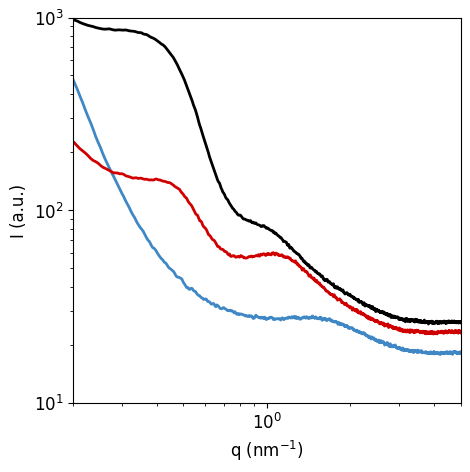

In [45]:
plt.figure(figsize=(5,5))
q, I = Exp.get_1d_SAXS(0)
plt.loglog(q, I, color='#3F88C5', linewidth=2)

q, I = Exp.get_1d_SAXS(20)
plt.loglog(q, I * 1.44, color='#D00000', linewidth=2)

q, I = Exp.get_1d_SAXS(102)
plt.loglog(q, I * 1.66, color='black', linewidth=2)

plt.xlim(0.2, 5)
plt.ylim(10, 1e3)
plt.xlabel('q (nm$^{-1}$)')
plt.ylabel('I (a.u.)')

In [47]:
1.73 * 0.4

0.6920000000000001

# Data

In [3]:
path = r"D:\НИР\2025-2026\PLA\Synology\SC5671-ID13\RAW_DATA\COPO-500-STR75C-2\sc5671_COPO-500-STR75C-2.h5"
file = h5py.File(path, 'r')
data = file['COPO-500-STR75C-2_fiber_run1_1.1']['measurement']['eiger']
img = data[99]

poni = r"D:\НИР\2025-2026\PLA\Synology\SC5671-ID13\PROCESSED_DATA\al2o3_a1.poni"
ai = pyFAI.load(poni)

mask = r"D:\НИР\2025-2026\PLA\Synology\SC5671-ID13\PROCESSED_DATA\mask1.edf"
img_mask = fabio.open(mask).data

# ...
# ...
# ...

[]

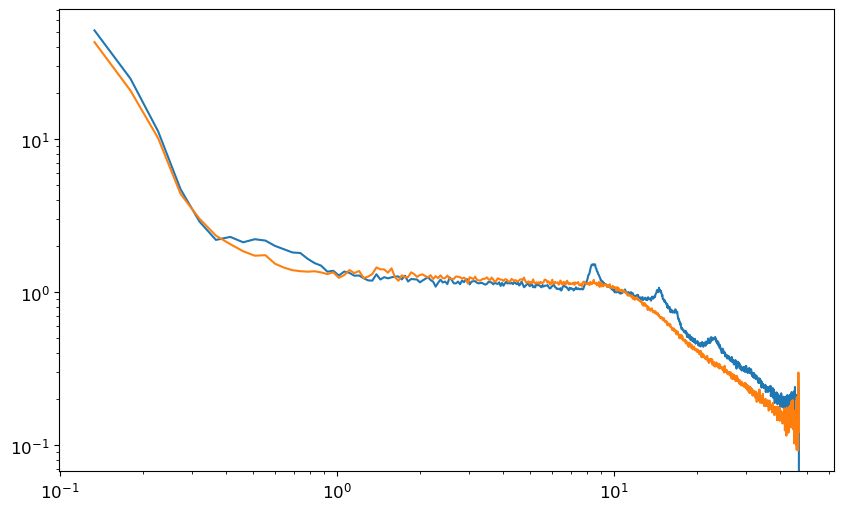

In [4]:
img = data[10]
q, I = ai.integrate1d(img, 1000, mask=img_mask, unit='q_nm^-1')
plt.plot(q,I)

img = data[150]
q, I = ai.integrate1d(img, 1000, mask=img_mask, unit='q_nm^-1')
plt.plot(q,I)

plt.semilogx()
plt.semilogy()

# Function

In [11]:
def integrate1d(path_edf, ai, npt, mask=None, unit='q_nm^-1'):
    
    img = fabio.open(path_edf).data
    res_1D = ai.integrate1d(img, npt, mask=mask, unit=unit)
        
    return res_1D[0], res_1D[1]

# Analysis

(0.1, 3)

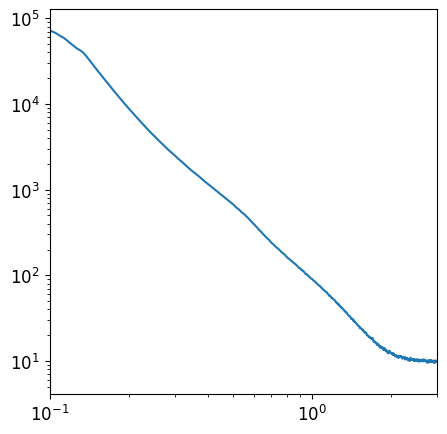

In [16]:
q, I = Some_Experiment.get_1d_SAXS()


plt.figure(figsize=(5,5))
plt.plot(q, I)

p, cov = curve_fit(linear, q, I)

plt.semilogx()
plt.semilogy()
plt.xlim(0.1, 3)
